# DeepMetrix- M5 Sales Forecasting — Baseline v2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Config
PARQUET_PATH = "/content/drive/My Drive/walmart_stores/processed/df_final.parquet"
N_ROW_GROUPS = 15
TARGET       = 'sales'
DATE_COL     = 'date'
PRICE_COL    = 'sell_price'
HORIZON      = 28
SEED         = 42

np.random.seed(SEED)
print('Imports OK')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Imports OK


## Load data

In [ ]:
pf = pq.ParquetFile(PARQUET_PATH)
row_group_idx = np.random.RandomState(SEED).choice(pf.num_row_groups, size=N_ROW_GROUPS, replace=False)
dfs = [pf.read_row_group(int(i)).to_pandas() for i in row_group_idx]
df = pd.concat(dfs, ignore_index=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df[DATE_COL].min()} -> {df[DATE_COL].max()}')
print(f'day_number range: {df["day_number"].min()} -> {df["day_number"].max()}')

Shape: (1843200, 34)
Date range: 2011-01-29 00:00:00 -> 2016-05-22 00:00:00
day_number range: 1 -> 1941


## Preprocessing



In [ ]:
DROP_COLS = ['item_store_id', DATE_COL, 'walmart_year_week', 'month_name', 'weekday']
df = df.drop(columns=DROP_COLS, errors='ignore')

CAT_COLS = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name', 'event_type']
for c in CAT_COLS:
    if c in df.columns and df[c].dtype.name != 'category':
        df[c] = df[c].astype('category')

# is_month_start / is_month_end sometimes come through as datetime64 instead of bool
for c in ['is_month_start', 'is_month_end']:
    if c in df.columns and df[c].dtype != bool:
        df[c] = df[c].astype(bool)

bool_cols = df.select_dtypes('bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype('int8')

print('Dtypes after preprocessing:')
print(df.dtypes.value_counts())
print(f'\nRemaining nulls (expected: lag/rolling columns only):')
print(df.isnull().sum()[df.isnull().sum() > 0])

Dtypes after preprocessing:
int16       7
int8        6
float64     5
float32     4
category    1
category    1
category    1
category    1
category    1
category    1
category    1
Name: count, dtype: int64

Remaining nulls (expected: lag/rolling columns only):
lag_7                     6657
lag_28                   26628
rolling_mean_7            6657
rolling_mean_28          26628
rolling_std_7             6657
price_change               951
price_rolling_mean_4w     3804
dtype: int64


## Train/validation split

Time-based, `cutoff = max_day - HORIZON`, matching M5's official 28-day evaluation convention. Verified for no gap/overlap.

In [ ]:
max_day = df['day_number'].max()
cutoff  = max_day - HORIZON

train_df = df[df['day_number'] <= cutoff].copy()
valid_df = df[df['day_number'] >  cutoff].copy()

assert train_df['day_number'].max() + 1 == valid_df['day_number'].min(), 'gap or overlap in split'
assert valid_df['day_number'].nunique() == HORIZON, 'validation window is not a full 28 days'

FEATURES = [c for c in df.columns if c != TARGET]
CAT_FEATURES = [c for c in CAT_COLS if c in FEATURES]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES], valid_df[TARGET]

print(f'Train: {X_train.shape}  |  Validation: {X_valid.shape}')
print(f'Cutoff day: {cutoff}  |  Max day: {max_day}')

Train: (1816572, 28)  |  Validation: (26628, 28)
Cutoff day: 1913  |  Max day: 1941


## Model


In [ ]:
lgb_params = {
    'objective'              : 'tweedie',
    'tweedie_variance_power' : 1.3,
    'metric'                 : 'rmse',
    'learning_rate'          : 0.03,
    'num_leaves'             : 95,
    'max_depth'              : -1,
    'min_child_samples'      : 10,
    'feature_fraction'       : 0.8,
    'bagging_fraction'       : 0.8,
    'bagging_freq'           : 1,
    'reg_alpha'               : 0.1,
    'reg_lambda'              : 0.1,
    'n_jobs'                  : -1,
    'seed'                    : SEED,
    'verbose'                 : -1,
}

dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=CAT_FEATURES, free_raw_data=False)
dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain, categorical_feature=CAT_FEATURES, free_raw_data=False)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]

model = lgb.train(
    params          = lgb_params,
    train_set       = dtrain,
    num_boost_round = 1000,
    valid_sets      = [dtrain, dvalid],
    valid_names     = ['train', 'valid'],
    callbacks       = callbacks,
)

print(f'\nBest iteration: {model.best_iteration}')

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 2.03243	valid's rmse: 2.05782
[200]	train's rmse: 1.94349	valid's rmse: 2.02393
[300]	train's rmse: 1.90066	valid's rmse: 2.02449
Early stopping, best iteration is:
[260]	train's rmse: 1.91673	valid's rmse: 2.01838

Best iteration: 260


In [ ]:
y_pred_train = np.clip(model.predict(X_train, num_iteration=model.best_iteration), 0, None)
y_pred_valid = np.clip(model.predict(X_valid, num_iteration=model.best_iteration), 0, None)

## Metrics



In [ ]:
def compute_metrics(y_true, y_pred, label='Validation'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    print(f'\n-- {label} --')
    print(f'  MAE      : {mae:.4f}')
    print(f'  RMSE     : {rmse:.4f}')
    print(f'  MAPE (%) : {mape:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

train_metrics = compute_metrics(y_train, y_pred_train, label='Train')
valid_metrics = compute_metrics(y_valid, y_pred_valid, label='Validation')


-- Train --
  MAE      : 0.7386
  RMSE     : 1.9167
  MAPE (%) : 41.0360

-- Validation --
  MAE      : 0.9617
  RMSE     : 2.0184
  MAPE (%) : 53.0578


## WRMSSE — full 12-level hierarchy


In [ ]:
LEVELS = [
    ('Total',                []),
    ('State',                ['state_id']),
    ('Store',                ['store_id']),
    ('Category',             ['cat_id']),
    ('Department',           ['dept_id']),
    ('State x Category',     ['state_id', 'cat_id']),
    ('State x Department',   ['state_id', 'dept_id']),
    ('Store x Category',     ['store_id', 'cat_id']),
    ('Store x Department',   ['store_id', 'dept_id']),
    ('Item',                 ['item_id']),
    ('Item x State',         ['item_id', 'state_id']),
    ('Item x Store',         ['item_id', 'store_id']),
]

def series_daily(df_src, group_cols, value_col=TARGET):
    """Sum value_col per series per day_number. Returns wide-key group_cols + '__key__'."""
    d = df_src.copy()
    if not group_cols:
        d['__key__'] = 'total'
        keys = ['__key__']
    else:
        keys = group_cols
    return d.groupby(keys + ['day_number'], observed=True)[value_col].sum().reset_index(), keys

def level_wrmsse(train_full, valid_actual, valid_pred, group_cols):
    keys = group_cols if group_cols else ['__key__']

    # naive one-step MSE per series over full train history
    train_daily, keys = series_daily(train_full, group_cols, TARGET)
    train_daily = train_daily.sort_values(keys + ['day_number'])
    train_daily['diff_sq'] = train_daily.groupby(keys, observed=True)[TARGET].diff() ** 2
    naive_mse = train_daily.groupby(keys, observed=True)['diff_sq'].mean().rename('naive_mse').reset_index()

    # forecast MSE per series over the validation horizon
    v = valid_actual.copy()
    v['__pred__'] = valid_pred
    if not group_cols:
        v['__key__'] = 'total'
    actual_daily = v.groupby(keys + ['day_number'], observed=True)[TARGET].sum().reset_index()
    pred_daily   = v.groupby(keys + ['day_number'], observed=True)['__pred__'].sum().reset_index()
    fc = actual_daily.merge(pred_daily, on=keys + ['day_number'])
    fc['sq_err'] = (fc[TARGET] - fc['__pred__']) ** 2
    forecast_mse = fc.groupby(keys, observed=True)['sq_err'].mean().rename('forecast_mse').reset_index()

    # weight = $ sales share in last 28 train days
    last28 = train_full[train_full['day_number'] > train_full['day_number'].max() - HORIZON].copy()
    if not group_cols:
        last28['__key__'] = 'total'
    last28['__dollar__'] = last28[TARGET] * last28[PRICE_COL]
    weights = last28.groupby(keys, observed=True)['__dollar__'].sum().rename('dollar_sales').reset_index()
    total_dollar = weights['dollar_sales'].sum()
    weights['weight'] = weights['dollar_sales'] / total_dollar if total_dollar > 0 else 0

    merged = naive_mse.merge(forecast_mse, on=keys).merge(weights, on=keys)
    merged = merged[merged['naive_mse'] > 0]
    merged['rmsse'] = np.sqrt(merged['forecast_mse'] / merged['naive_mse'])

    return float((merged['weight'] * merged['rmsse']).sum())

level_scores = {}
valid_actual_df = valid_df[['day_number', TARGET] + [c for c in ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'] if c in valid_df.columns]].copy()

for name, group_cols in LEVELS:
    score = level_wrmsse(train_df, valid_actual_df, y_pred_valid, group_cols)
    level_scores[name] = score
    print(f'{name:22s}: {score:.4f}')

final_wrmsse = float(np.mean(list(level_scores.values())))
print(f'\nFinal WRMSSE (mean across 12 levels): {final_wrmsse:.4f}')

Total                 : 0.7210
State                 : 0.7416
Store                 : 0.7677
Category              : 0.7286
Department            : 0.7583
State x Category      : 0.7661
State x Department    : 0.7812
Store x Category      : 0.7924
Store x Department    : 0.7949
Item                  : 0.8283
Item x State          : 0.8467
Item x Store          : 0.8828

Final WRMSSE (mean across 12 levels): 0.7841


## Diagnostics (borrowed)

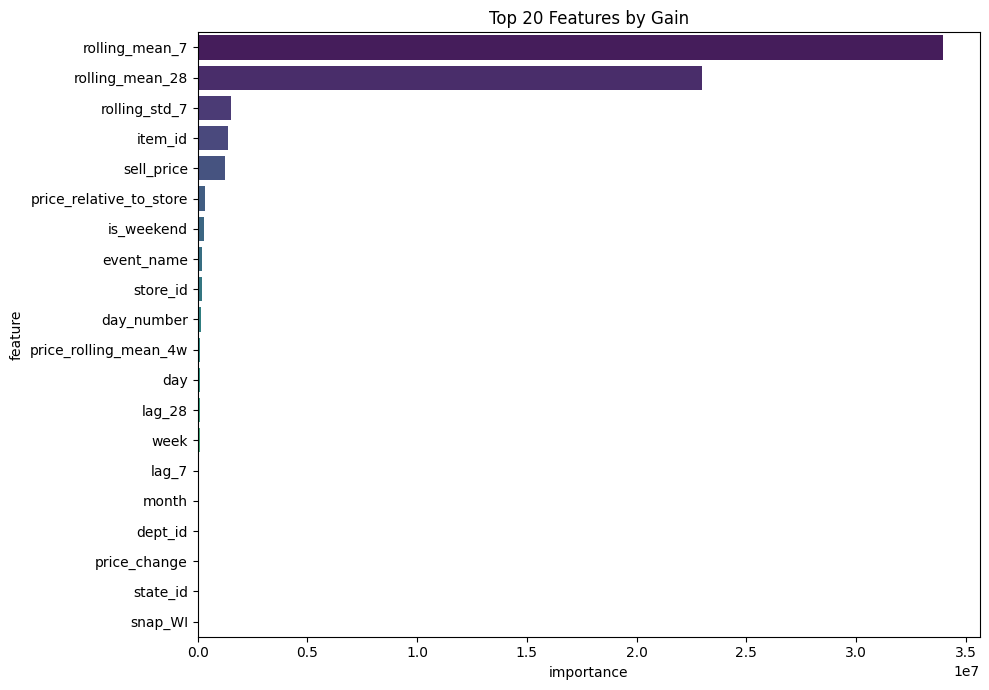

                feature   importance
         rolling_mean_7 3.394846e+07
        rolling_mean_28 2.296509e+07
          rolling_std_7 1.498943e+06
                item_id 1.378405e+06
             sell_price 1.235638e+06
price_relative_to_store 3.541515e+05
             is_weekend 2.767205e+05
             event_name 1.836562e+05
               store_id 1.804381e+05
             day_number 1.363706e+05
  price_rolling_mean_4w 1.099671e+05
                    day 9.570367e+04
                 lag_28 9.184933e+04
                   week 8.719475e+04
                  lag_7 5.828364e+04
                  month 5.374775e+04
                dept_id 2.848584e+04
           price_change 2.159666e+04
               state_id 2.102464e+04
                snap_WI 2.045155e+04


In [ ]:
fi = pd.DataFrame({
    'feature'   : model.feature_name(),
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=fi.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Features by Gain')
plt.tight_layout(); plt.show()

print(fi.head(20).to_string(index=False))

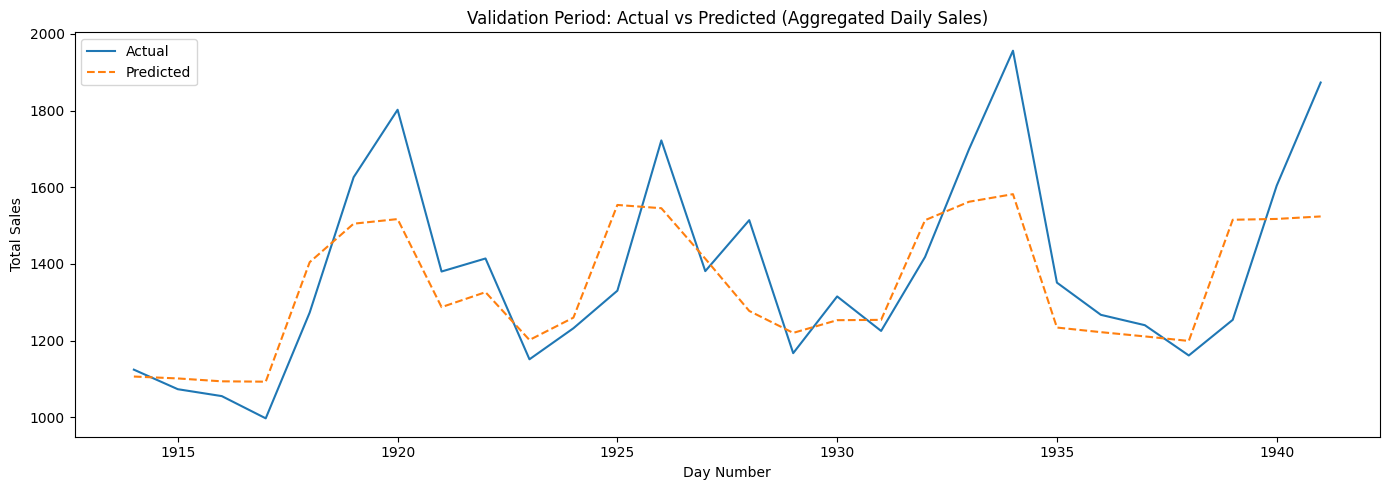

In [ ]:
valid_plot = valid_df[['day_number']].copy()
valid_plot['actual']    = y_valid.values
valid_plot['predicted'] = y_pred_valid

daily_cmp = valid_plot.groupby('day_number')[['actual', 'predicted']].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_cmp['day_number'], daily_cmp['actual'],    label='Actual',    linewidth=1.5)
plt.plot(daily_cmp['day_number'], daily_cmp['predicted'], label='Predicted', linewidth=1.5, linestyle='--')
plt.title('Validation Period: Actual vs Predicted (Aggregated Daily Sales)')
plt.xlabel('Day Number'); plt.ylabel('Total Sales')
plt.legend(); plt.tight_layout(); plt.show()

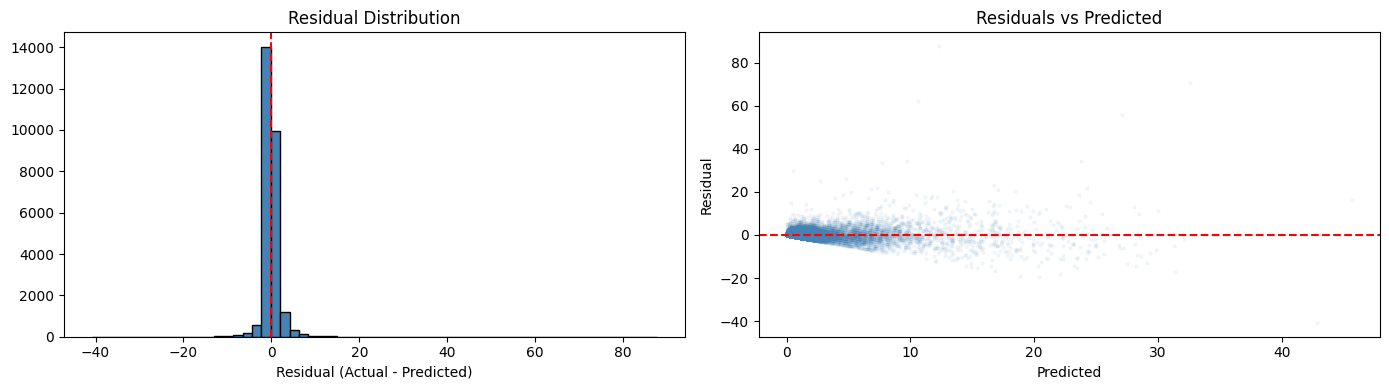

Residual mean : 0.0419
Residual std  : 2.0179


In [ ]:
residuals = y_valid.values - y_pred_valid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=60, edgecolor='black', color='steelblue')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].axvline(0, color='red', linestyle='--')

axes[1].scatter(y_pred_valid, residuals, alpha=0.05, s=5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')

plt.tight_layout(); plt.show()

print(f'Residual mean : {residuals.mean():.4f}')
print(f'Residual std  : {residuals.std():.4f}')

## Summary

In [ ]:
summary = pd.DataFrame({
    'Split'   : ['Train', 'Validation'],
    'MAE'     : [train_metrics['MAE'],      valid_metrics['MAE']],
    'RMSE'    : [train_metrics['RMSE'],     valid_metrics['RMSE']],
    'MAPE (%)': [train_metrics['MAPE (%)'], valid_metrics['MAPE (%)']],
})
summary['WRMSSE'] = [None, final_wrmsse]
display(summary.set_index('Split').round(4))

print('\nPer-level WRMSSE:')
for name, score in level_scores.items():
    print(f'  {name:22s}: {score:.4f}')

,MAE,RMSE,MAPE (%),WRMSSE
Split,,,,
Train,0.7386,1.9167,41.0360,NaN
Validation,0.9617,2.0184,53.0578,0.7841



Per-level WRMSSE:
  Total                 : 0.7210
  State                 : 0.7416
  Store                 : 0.7677
  Category              : 0.7286
  Department            : 0.7583
  State x Category      : 0.7661
  State x Department    : 0.7812
  Store x Category      : 0.7924
  Store x Department    : 0.7949
  Item                  : 0.8283
  Item x State          : 0.8467
  Item x Store          : 0.8828
